# Multiverse analysis

Appendix supporting the paper's three sensitivity analyses (prompt wording,
number of clusters, lens-scheme draw). Instead of varying one analytical
choice at a time, this notebook runs the full Cartesian product of
defensible choices and reports the distribution of each headline finding
across the resulting multiverse.

**Methodology**: Bell, Kampman, Dodge, Lawrence (2022),
*Modeling the Machine Learning Multiverse*, NeurIPS. For an exhaustive
multiverse of this size (hundreds of configurations, each a sub-second
evaluation), we iterate directly rather than using the GP-surrogate
scheme their paper introduces for expensive ML hyperparameter spaces.

**Dimensions** (cheap — no new LLM calls, reuse existing artifacts):
- `lens_run_idx` : 1..N draws of the LLM lens-grouping step
- `sigma2_rule` : alternative selection rules on the stability curve
- `baseline` : tech-weighted vs doc-weighted non-AI baseline (R2)
- `threshold` : cross-cutting entropy threshold (R1)

**Dimensions** (expensive — require upstream re-runs; stubbed below):
- `k` : 60, 75, 90 (needs M6d outputs)
- `prompt` : V0, V1, V3 (needs M6b outputs)

**Evaluation functions**:
- ℓ_R1 : fraction of concern clusters that are cross-cutting
- ℓ_R2 : AI-vs-non-AI pp difference on the top-AI-salient lens
- ℓ_R3 : standard deviation of normalised AI concern entropy across the
  four time windows (smaller = more "stable spread")

Outputs: `outputs/multiverse_results.csv` (full table) plus distribution
and variance-decomposition plots.

## Load pre-computed artifacts and the multiverse module

In [13]:
# @title Load pre-computed artifacts
from pathlib import Path
import json as _json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pub_dialogue.utils import show_status, show_complete, AccessStage, AddressStage

_access  = AccessStage()
_address = AddressStage(access=_access)
OUTPUT_FOLDER     = _access.output_folder
CHECKPOINT_FOLDER = _access.checkpoint_folder

print(f"Artifact folders: {OUTPUT_FOLDER} / {CHECKPOINT_FOLDER}")

Artifact folders: outputs / checkpoints


In [14]:
# @title Import the multiverse module
from pub_dialogue import multiverse as mv

print("Loaded multiverse module.")
print("  sigma² selection rules:", list(mv.SIGMA2_RULES.keys()))

Loaded multiverse module.
  sigma² selection rules: ['min_emd', 'min_emd_support_cap', 'median']


## One-time setup: prepare k=60 and k=90 variants

`prepare_k_variant` re-clusters the existing concern embeddings at a new k,
re-runs cluster labelling and LLM lens generation at that k, and runs the
σ squared sweep. It saves everything to `outputs/multiverse_sources/k{k}_V0/`
so the multiverse loader can find it later.

Running this once (per k) involves ~N lens-generation LLM calls per k;
re-runs short-circuit if the output folder already exists. Set
`overwrite=True` to force a fresh run.

In [15]:
# @title Prepare k=60 and k=90 variants (one-time setup, requires LLM client)
from pub_dialogue.client import LLMClient
import os

# API-key dance: same pattern as 01a's "Configure API access" cell
if not os.environ.get("OPENAI_API_KEY"):
    from getpass import getpass
    os.environ["OPENAI_API_KEY"] = getpass("Enter OPENAI_API_KEY: ")

client = LLMClient(model="gpt-4o-mini")

for k in [60, 90]:
    mv.prepare_k_variant(
        k=k,
        output_folder=OUTPUT_FOLDER,
        checkpoint_folder=CHECKPOINT_FOLDER,
        address_stage=_address,
        access_stage=_access,
        client=client,
        n_lens_runs=5,
        source_prompt="V0",
        overwrite=False,
    )

print()
print("k-variant preparation complete.")

[k=60] already prepared at outputs/multiverse_sources/k60_V0 — skipping (set overwrite=True to force)
[k=90] already prepared at outputs/multiverse_sources/k90_V0 — skipping (set overwrite=True to force)

k-variant preparation complete.


In [16]:
# @title Prepare V3 prompt variant at k=75 (one-time, ~$0.60 + ~1 hour)
# Re-extracts concern phrases from all ~1700 chunks under the V3 (strict
# decontextualisation) prompt, re-embeds, re-clusters at k=75, labels,
# generates N=5 lens mappings, runs σ² sweep.

for prompt in ["C_no_decon", "B_broader"]:
    mv.prepare_prompt_variant(
        prompt=prompt,
        k=75,
        output_folder=OUTPUT_FOLDER,
        checkpoint_folder=CHECKPOINT_FOLDER,
        address_stage=_address,
        access_stage=_access,
        client=client,
        n_lens_runs=5,
        overwrite=False,
    )

print()
print("Prompt variant preparation complete.")

[prompt=C_no_decon, k=75] already prepared at outputs/multiverse_sources/k75_C_no_decon — skipping
[prompt=B_broader, k=75] preparing variant at outputs/multiverse_sources/k75_B_broader


[prompt=B_broader] extracting from 10464 chunks (LLM)...


Extracting (B_broader):   0%|          | 0/10464 [00:00<?, ?it/s]

[prompt=B_broader] embedding 25617 phrases...
[prompt=B_broader, k=75] clustering...
[prompt=B_broader, k=75] extracting exemplars...
[prompt=B_broader, k=75] labelling clusters (LLM)...
[prompt=B_broader, k=75] generating 5 lens mappings (LLM)...
[prompt=B_broader, k=75] σ² sweep...
[prompt=B_broader, k=75] done. Artifacts at outputs/multiverse_sources/k75_B_broader

Prompt variant preparation complete.


## Define the multiverse

Edit `DIMENSIONS` to add or remove analytical choices. The defaults below
cover the four cheap dimensions and fix the expensive dimensions at their
baseline values (`k=75`, `prompt="V0"`). To extend to `k ∈ {60, 90}` or
`prompt ∈ {V1, V3}`, wire up the corresponding artifact loaders in
`pub_dialogue.multiverse.load_pipeline_artifacts` (currently stubbed with
`NotImplementedError`) and add those values to the dict.

In [17]:
# @title Define the dimensions (now spans V0 and V3 for prompt-probe)
# Note: V3 is only prepared at k=75 — we build the config list as a union
# of two sub-grids rather than a full Cartesian product.
DIMENSIONS_V0 = {
    "k":            [60, 75, 90],
    "prompt":       ["V0"],
    "lens_run_idx": [1, 2, 3, 4, 5],
    "sigma2_rule":  ["min_emd", "min_emd_support_cap", "median"],
    "baseline":     ["tech_weighted", "doc_weighted"],
    "threshold":    [0.4, 0.5, 0.6],
}
DIMENSIONS_V3 = {
    "k":            [75],
    "prompt":       ["C_no_decon", "B_broader"],
    "lens_run_idx": [1, 2, 3, 4, 5],
    "sigma2_rule":  ["min_emd", "min_emd_support_cap", "median"],
    "baseline":     ["tech_weighted", "doc_weighted"],
    "threshold":    [0.4, 0.5, 0.6],
}
DIMENSIONS = DIMENSIONS_V0  # used by variance_decomposition's dimension_cols

configs = (
    mv.enumerate_configurations(DIMENSIONS_V0)
    + mv.enumerate_configurations(DIMENSIONS_V3)
)
print(f"Multiverse size: {len(configs)} configurations "
      f"({len(mv.enumerate_configurations(DIMENSIONS_V0))} at V0, "
      f"{len(mv.enumerate_configurations(DIMENSIONS_V3))} at V3)")
print("First 3 configurations:")
for c in configs[:3]:
    print(" ", c)

Multiverse size: 450 configurations (270 at V0, 180 at V3)
First 3 configurations:
  MultiverseConfig(k=60, prompt='V0', lens_run_idx=1, sigma2_rule='min_emd', baseline='tech_weighted', threshold=0.4)
  MultiverseConfig(k=60, prompt='V0', lens_run_idx=1, sigma2_rule='min_emd', baseline='tech_weighted', threshold=0.5)
  MultiverseConfig(k=60, prompt='V0', lens_run_idx=1, sigma2_rule='min_emd', baseline='tech_weighted', threshold=0.6)


## Run the multiverse

Iterates `run_configuration` over every point in the multiverse. Bundles
are cached per `(k, prompt)` pair to avoid redundant disk reads; for the
default cheap-dimensions-only grid, that means a single artifact load
followed by fast per-configuration metric evaluations.

In [22]:
# @title Run every configuration and collect results
show_status("Running the multiverse...")

results_df = mv.run_multiverse(
    configs,
    output_folder=OUTPUT_FOLDER,
    checkpoint_folder=CHECKPOINT_FOLDER,
    compute_mixture_weights_fn=_address.compute_mixture_weights,
)

results_df.to_csv(OUTPUT_FOLDER / "multiverse_results.csv", index=False)
show_complete(f"Multiverse complete: {len(results_df)} rows written to multiverse_results.csv")

print()
print(results_df.describe(include='all').round(3).to_string())

multiverse:   0%|          | 0/450 [00:00<?, ?it/s]


              k prompt  lens_run_idx sigma2_rule       baseline  threshold   sigma2  n_lenses   ell_R1   ell_R2   ell_R3
count   450.000    450       450.000         450            450    450.000  450.000   450.000  450.000  450.000  450.000
unique      NaN      3           NaN           3              2        NaN      NaN       NaN      NaN      NaN      NaN
top         NaN     V0           NaN     min_emd  tech_weighted        NaN      NaN       NaN      NaN      NaN      NaN
freq        NaN    270           NaN         150            225        NaN      NaN       NaN      NaN      NaN      NaN
mean     75.000    NaN         3.000         NaN            NaN      0.500   13.470    10.160    0.647    4.218    0.022
std       9.497    NaN         1.416         NaN            NaN      0.082   33.978     0.925    0.151    2.626    0.004
min      60.000    NaN         1.000         NaN            NaN      0.400    0.100     8.000    0.373    0.006    0.015
25%      75.000    NaN         

## Distribution of each headline finding across the multiverse

For each of ℓ_R1, ℓ_R2 and ℓ_R3, plot the distribution of values across
the multiverse. A tight distribution supports a robust claim; a wide one
reveals that the finding depends on analytical choices.

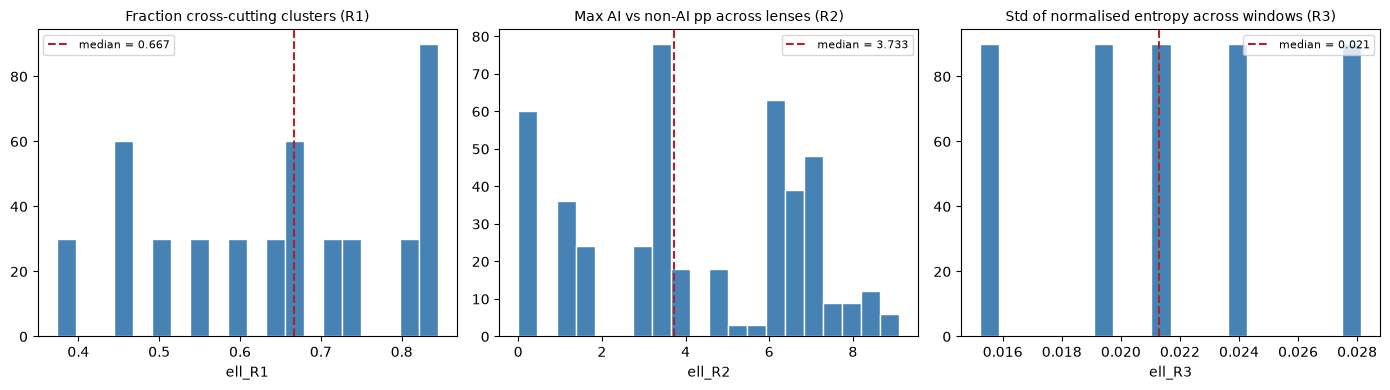

Summary statistics per metric:
        ell_R1   ell_R2   ell_R3
count  450.000  450.000  450.000
mean     0.647    4.218    0.022
std      0.151    2.626    0.004
min      0.373    0.006    0.015
25%      0.500    1.662    0.019
50%      0.667    3.733    0.021
75%      0.813    6.641    0.024
max      0.844    9.109    0.028


In [23]:
# @title Distribution histograms
metrics = [
    ("ell_R1", "Fraction cross-cutting clusters (R1)"),
    ("ell_R2", "Max AI vs non-AI pp across lenses (R2)"),
    ("ell_R3", "Std of normalised entropy across windows (R3)"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, label) in zip(axes, metrics):
    series = results_df[col].dropna()
    ax.hist(series, bins=20, color='steelblue', edgecolor='white')
    ax.axvline(series.median(), color='firebrick', linestyle='--',
               label=f'median = {series.median():.3f}')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "multiverse_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

print("Summary statistics per metric:")
print(results_df[['ell_R1', 'ell_R2', 'ell_R3']].describe().round(3).to_string())

## Variance decomposition — which choices matter

For each metric, report the fraction of variance explained by varying
each dimension on its own (between-group sum of squares / total sum of
squares). Dimensions with high variance share are the ones that materially
move the finding; dimensions with low share can be deprioritised in
future robustness checks.

**Caveat**: this is a one-way decomposition — shares do not sum to 1 in
the presence of interactions. It is a first-cut diagnostic. For a formal
decomposition that attributes interaction variance, consider Sobol
indices or a full factorial ANOVA.

metric    dimension  variance_share
ell_R1    threshold           0.841
ell_R1       prompt           0.121
ell_R1            k           0.045
ell_R1 lens_run_idx           0.000
ell_R1  sigma2_rule           0.000
ell_R1     baseline           0.000
ell_R2  sigma2_rule           0.452
ell_R2            k           0.230
ell_R2       prompt           0.215
ell_R2 lens_run_idx           0.001
ell_R2     baseline           0.000
ell_R2    threshold           0.000
ell_R3       prompt           0.866
ell_R3            k           0.091
ell_R3  sigma2_rule           0.000
ell_R3     baseline           0.000
ell_R3    threshold           0.000
ell_R3 lens_run_idx           0.000


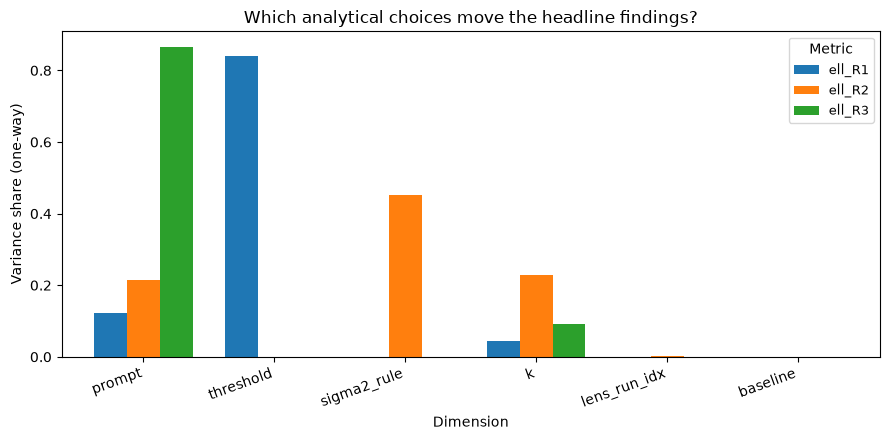

In [24]:
# @title Variance share per dimension
dimension_cols = ["k", "prompt", "lens_run_idx", "sigma2_rule", "baseline", "threshold"]

decomp_rows = []
for col, label in metrics:
    decomp = mv.variance_decomposition(results_df, col, dimension_cols)
    decomp.insert(0, "metric", col)
    decomp_rows.append(decomp)

decomp_df = pd.concat(decomp_rows, ignore_index=True)
decomp_df.to_csv(OUTPUT_FOLDER / "multiverse_variance_decomposition.csv", index=False)

print(decomp_df.round(3).to_string(index=False))

# Grouped bar chart: variance share by (metric, dimension)
pivot = decomp_df.pivot(index="dimension", columns="metric", values="variance_share")
pivot = pivot.reindex(sorted(pivot.index, key=lambda d: -pivot.loc[d].mean()))

ax = pivot.plot(kind="bar", figsize=(9, 4.5), width=0.75)
ax.set_ylabel("Variance share (one-way)")
ax.set_xlabel("Dimension")
ax.set_title("Which analytical choices move the headline findings?")
ax.legend(title="Metric", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_FOLDER / "multiverse_variance_shares.png", dpi=150, bbox_inches='tight')
plt.show()

## Canonical configuration in context

The notebook's current paper claims come from a single configuration (the
"canonical" run — the one in `01a`'s σ²-sweep output). Here we locate that
configuration in the multiverse distribution for each metric, so the
paper can report "canonical value X; multiverse interval [Y, Z]
(nn/mm percentile)".

In [25]:
# @title Locate the canonical configuration in each distribution
CANONICAL = mv.MultiverseConfig(
    k=75,
    prompt="V0",
    lens_run_idx=1,
    sigma2_rule="min_emd",
    baseline="tech_weighted",
    threshold=0.5,
)
canonical_dict = CANONICAL.as_dict()
print("Canonical configuration:", canonical_dict)

# Find the matching row in results_df
match_mask = pd.Series([True] * len(results_df))
for k_, v in canonical_dict.items():
    if k_ in results_df.columns:
        match_mask &= results_df[k_] == v

if not match_mask.any():
    print("WARNING: canonical configuration not in the multiverse grid. "
          "Add its values to DIMENSIONS or verify the defaults.")
else:
    canonical_row = results_df[match_mask].iloc[0]
    print()
    print("Canonical row:")
    for col, label in metrics:
        series = results_df[col].dropna()
        canonical_val = canonical_row[col]
        pct = (series <= canonical_val).mean() * 100
        print(f"  {label}: {canonical_val:.3f}  "
              f"(multiverse p{pct:.0f}, "
              f"range [{series.min():.3f}, {series.max():.3f}])")

Canonical configuration: {'k': 75, 'prompt': 'V0', 'lens_run_idx': 1, 'sigma2_rule': 'min_emd', 'baseline': 'tech_weighted', 'threshold': 0.5}

Canonical row:
  Fraction cross-cutting clusters (R1): 0.653  (multiverse p47, range [0.373, 0.844])
  Max AI vs non-AI pp across lenses (R2): 3.544  (multiverse p45, range [0.006, 9.109])
  Std of normalised entropy across windows (R3): 0.019  (multiverse p40, range [0.015, 0.028])


## Headline distribution summary (paper-ready phrasing)

A one-line "distribution across the multiverse" summary for each headline,
to drop into the paper's robustness paragraph.

In [26]:
# @title Paper-ready one-line summaries
for col, label in metrics:
    series = results_df[col].dropna()
    print(f"{label}:")
    print(f"  canonical configuration: see cell above")
    print(f"  multiverse ({len(series)} configurations): "
          f"median {series.median():.3f}, "
          f"IQR [{series.quantile(0.25):.3f}, {series.quantile(0.75):.3f}], "
          f"range [{series.min():.3f}, {series.max():.3f}]")
    print()

Fraction cross-cutting clusters (R1):
  canonical configuration: see cell above
  multiverse (450 configurations): median 0.667, IQR [0.500, 0.813], range [0.373, 0.844]

Max AI vs non-AI pp across lenses (R2):
  canonical configuration: see cell above
  multiverse (450 configurations): median 3.733, IQR [1.662, 6.641], range [0.006, 9.109]

Std of normalised entropy across windows (R3):
  canonical configuration: see cell above
  multiverse (450 configurations): median 0.021, IQR [0.019, 0.024], range [0.015, 0.028]



## What's covered in this multiverse, and what remains

The multiverse above spans five dimensions:

- `k` ∈ {60, 75, 90} — number of KMeans clusters
- `lens_run_idx` ∈ {1..5} — independent LLM lens-grouping draws
- `sigma2_rule` — three alternative σ² selection rules on the stability curve
- `baseline` — tech-weighted vs document-weighted non-AI baseline
- `threshold` — three cross-cutting entropy thresholds

The k variants were prepared once by `prepare_k_variant` (re-clustering
the existing embeddings and regenerating lens mappings at each k) and
cached under `outputs/multiverse_sources/`.

**Remaining future work: the prompt dimension.** Varying the extraction
prompt (V0 / V1 / V3) across the full corpus would require re-running the
LLM extraction pipeline from scratch for each variant (~$0.50 and ~1 hour
each), rather than reusing cached outputs as this notebook does for `k`.
The paper's M6(b) analysis gives a sample-level agreement comparison
between the variants; a full prompt-level extension to the multiverse is
left as future work.